<a href="https://colab.research.google.com/github/aman8122/data-science-Assignments/blob/main/week3_Aman_Sain_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Country Segmentation System (End-to-End ML Project)**

##**Objective**
**To segment countries based on socio-economic indicators using unsupervised learning (K-Means, DBSCAN) and validate patterns using ensemble learning(Random Forest, XGBoost) to derive actionable insights.**

###**Import Libraries**

**Reason:Import all required libary in beginining for better readability**

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA


###**Load Dataset**

**Reason:Load dataset and the understand the number of observations**

In [202]:
from google.colab import files
uploaded=files.upload()
co_df = pd.read_csv("Country-data.csv")
co_df.head()

Saving Country-data.csv to Country-data (2).csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


###**Data Understanding**

**Reason:Detect missing values, duplicates, and explore feature distributions before building the model.**

In [203]:
co_df.shape #shape


(167, 10)

In [204]:
co_df.info() #infomation about data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [205]:
 #check the missing value
 co_df.isnull().sum()



,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [206]:
#stats summery of dataset
co_df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [207]:

#check the duplicate values
co_df.duplicated().sum()

np.int64(0)

###**Data preprocessing**

**Reason:Country coloumn is not numeric feature.we can remove the feature..clustring work on only numeric features**

In [208]:
#drop the object column in the dataset
co_df = co_df.drop(['country'],axis=1)

###**Exploratory Data Analysis**

**Reason: Explore relationship between different socio-economic indicators and check highly correlation features**

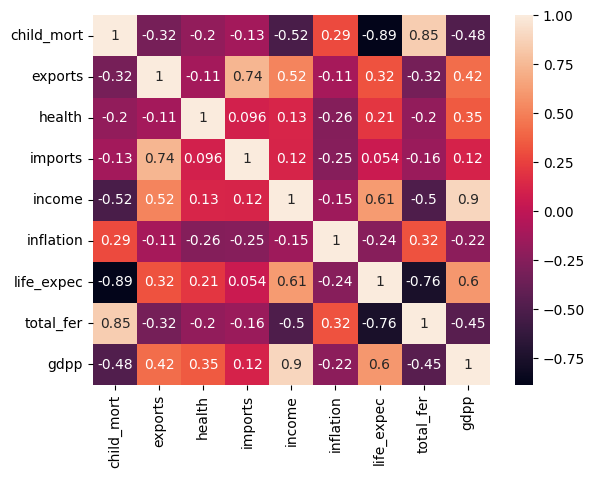

In [209]:
#correlation heatmap
sns.heatmap(co_df.corr(),annot=True)
plt.show()

**Reason:we can check  data  distribution the columns**

In [210]:
#checks skewsness of feature by the order
co_df.skew().sort_values(ascending=False)

,0
inflation,5.154049
exports,2.445824
income,2.231480
gdpp,2.218051
imports,1.905276
child_mort,1.450774
total_fer,0.967092
health,0.705746
life_expec,-0.970996


###**Feature Engineering**

**Reason: Such factors had strong correlations with many other socio-economic factors. By excluding them, the level of redundancy and multicollinearity was minimized while retaining all information from the data set.**

In [211]:
#drop highly correalated feature
co_df=co_df.drop(['income','life_expec','total_fer','imports'],axis=1)



**Reason: This variable had high positive skewness. By applying log transformation, we could minimize the effect of skewness and increase clustering efficiency.**

In [212]:
#log_trasfromation
cols=['exports','child_mort']

co_df[cols]=np.log1p(co_df[cols])

**Reason: Standard Scaler use because a clustring algorithm need scaling before trasfrom the data**

In [231]:
#standard Scaler
scaler = StandardScaler()
X_scale= scaler.fit_transform(co_df)



###**K-Means Clustering**

**Reason: The Elbow Method technique uses the Within-Cluster Sum of Squares to find the best value of K in clustering. The value at which there is a significant reduction is chosen because of the balance between over-fitting and under-fitting.**

In [232]:
#The Elbow Method
wcss=[]
for i in range(1,11):
  k=KMeans(n_clusters=i,init='k-means++',random_state=42)
  k.fit(X_scale)
  wcss.append(k.inertia_)

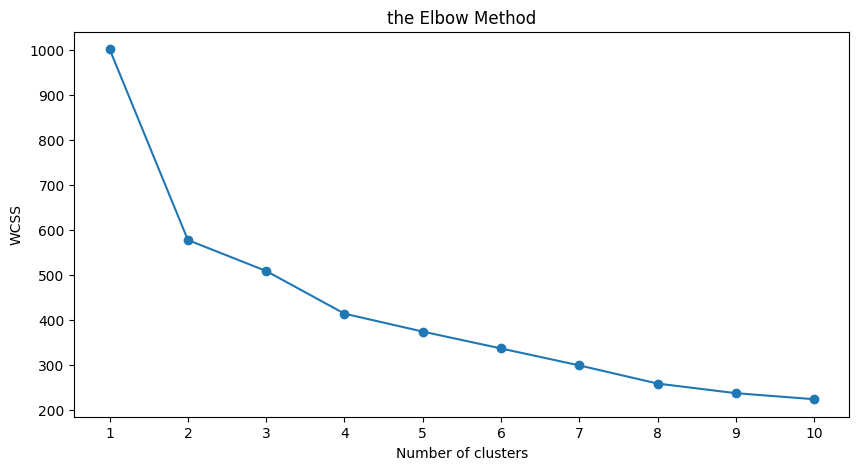

In [233]:
#Line plot
plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title('the Elbow Method')
plt.xlabel('Number of clusters')
plt.xticks(range(1,11))
plt.ylabel('WCSS')
plt.show()

**Reason:K-means algorithm is used for clustering nations using their socio-economic similarities by minimizing the intra-cluster variance through centroid-based distance optimization in the standardized feature space.**

In [234]:
kmean=KMeans(n_clusters=2,random_state=42)
labels=kmean.fit_predict(X_scale)

In [235]:
#add on clusters
co_df['labels']=labels

In [236]:
#data check
co_df.head()

,child_mort,exports,health,inflation,gdpp,labels
0,4.513055,2.397895,7.58,9.44,553,0
1,2.867899,3.367296,6.55,4.49,4090,0
2,3.342862,3.673766,4.17,16.10,4460,0
3,4.787492,4.147885,2.85,22.40,3530,0
4,2.424803,3.839452,6.03,1.44,12200,0


In [237]:
#count value in label feature
co_df.groupby('labels').mean()




,child_mort,exports,health,inflation,gdpp
labels,,,,,
0,3.659487,3.421107,6.046695,9.923254,4036.559322
1,1.847184,3.871221,8.667551,2.624939,34463.265306


In [238]:
co_df['labels'].value_counts()

,count
labels,
0,118
1,49



**Reason: Silhouette Score was employed as an index for evaluating the goodness of clusters through the assessment of their cohesion and separation measures.**

In [239]:
score=silhouette_score(X_scale, co_df['labels'])
print(score)

0.45164762690841276


**PCA reduces dimensions to 2D for better visualization of cluster separation.**

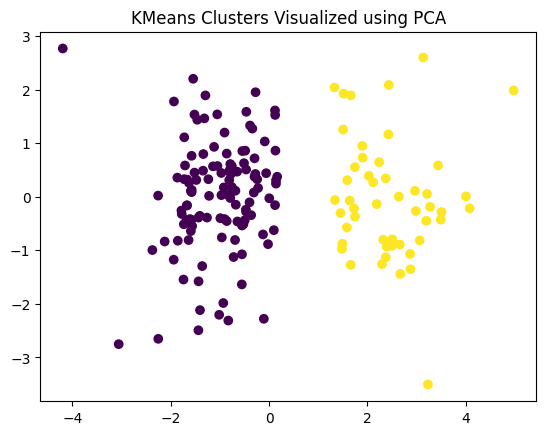

In [240]:
# PCA for visualization
X_pc=PCA(n_components=2).fit_transform(X_scale)
plt.scatter(X_pc[:,0],X_pc[:,1],c=labels,cmap='viridis')
plt.title("KMeans Clusters Visualized using PCA")
plt.show()

###**Ensemble Validation and end to end model buliding using xgboost and random forest**

 **Reason:The clusters formed through K-Means technique are considered as pseudo-labels for checking whether the identified clusters were separable or not using socio-economic parameters.**

In [241]:
#Sepreate input and output
X=co_df.drop('labels',axis=1)
y=co_df['labels']

In [242]:
#Train test split
X_train,X_test,y_train,y_test=train_test_split(X, y,test_size=0.20,random_state=7,stratify=y)

**Reason: Stacking involves stacking up various models that will take advantage of each other’s strength. In this regard, Random Forest helps in identifying non-linear relationships, whereas XGBoost helps in gradient boosting. Logistic Regression serves as a meta-learner.**

In [243]:
#Bulid base models for stacking
base_model1= RandomForestClassifier(random_state=40, class_weight='balanced',max_depth=5)
base_model2= XGBClassifier(random_state=42, eval_metric='mlogloss',max_depth=3)


In [244]:
#bulid meta model and cross validation
stacks=StackingClassifier(estimators=[("rf", base_model1),("xgb", base_model2)],final_estimator=LogisticRegression(max_iter=1000,random_state=100),cv=10,n_jobs=-1)


In [245]:
#Create pipiline
pipe=Pipeline([("s",stacks)])


In [246]:
#Train model
pipe.fit(X_train, y_train)


Pipeline(steps=[('s',
                 StackingClassifier(cv=10,
                                    estimators=[('rf',
                                                 RandomForestClassifier(class_weight='balanced',
                                                                        max_depth=5,
                                                                        random_state=40)),
                                                ('xgb',
                                                 XGBClassifier(base_score=None,
                                                               booster=None,
                                                               callbacks=None,
                                                               colsample_bylevel=None,
                                                               colsample_bynode=None,
                                                               colsample_bytree=None,
                                                               device=None,
                                                               early_stopping_rounds=None,
                                                               enable_categorical=False,
                                                               eval_metric='...
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=3,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...))],
                                    final_estimator=LogisticRegression(max_iter=1000,
                                                                       random_state=100),
                                    n_jobs=-1))])

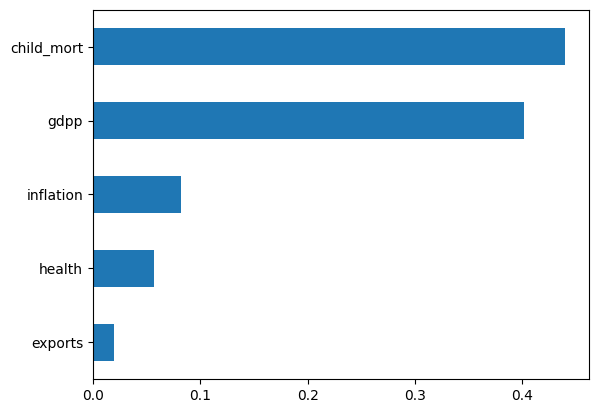

In [247]:

#feature importance
X = co_df.drop('labels', axis=1)
rf=RandomForestClassifier()
rf.fit(X, co_df['labels'])
pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.show()

###**Evalution model and f1 score**

In [248]:
print(pipe.score(X_train, y_train))
print(pipe.score(X_test, y_test))
from sklearn.metrics import classification_report
y_pred=pipe.predict(X_test)
print(classification_report(y_test, y_pred))

1.0
0.9705882352941176
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       1.00      0.90      0.95        10

    accuracy                           0.97        34
   macro avg       0.98      0.95      0.96        34
weighted avg       0.97      0.97      0.97        34



###**Country Segmentation Project – Key Insights**
**1. Successful Natural Country Segmentation
Using K-Means clustering for country segmentation proved successful.
Two distinct country segments:
Developed countries
Developing countries**

**2. Difference Between Healthcare and Economic Indicators Within Clusters
The developed cluster has the following characteristics:
Stronger healthcare indicators
Lower inflation levels
The developing cluster has the following characteristics:
Poorer healthcare systems
Economic instability**

**3. Importance of Feature Engineering
Log transformation helped to reduce skewness for the imbalanced features.
Feature removal helped to remove redundant variables due to correlation.
Standard scaling helped to ensure an equal importance of variables.**

**4. Validity of Unsupervised Clustering (K-Means)
Using K-Means clustering to form socio-economic groupings was quite effective.
Suggests existence of natural socio-economic structure.**
5. **Silhouette Score
The silhouette score suggests proper cluster separation.
The variability in silhouette scores is due to the following factors:
Randomness**


**6. Validation of Clusters Using Ensemble Algorithms
Random Forest and XGBoost algorithms learn the pattern in cluster separation.
Indicates that cluster separation is not a coincidence, but rather feature-driven.**
**7. Real-Life Interpretation of Clusters
Cluster 0 = Developing / poor countries
Cluster 1 = Developed / rich countries**